<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Linear%20Regression/credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arockiaselciaa/creditcardcsv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardcsv' dataset.
Path to dataset files: /kaggle/input/creditcardcsv


In [3]:
import warnings
import pandas as pd

warnings.filterwarnings("ignore")
df = pd.read_csv("/kaggle/input/creditcardcsv/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
len(df)

284807

In [5]:
df['Class'].unique()

array([0, 1])

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


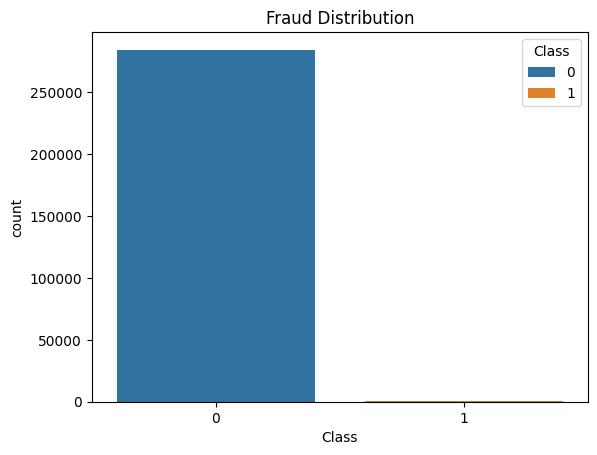

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(df, x='Class', hue='Class')
plt.title("Fraud Distribution")
plt.show()

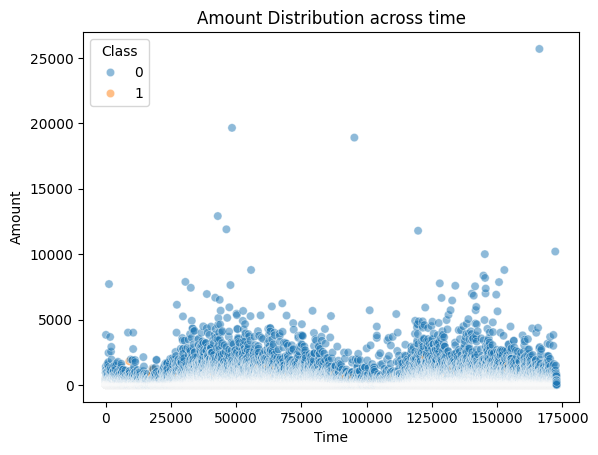

In [8]:
sns.scatterplot(df, x='Time', y='Amount', alpha=0.5, hue='Class')
plt.title("Amount Distribution across time")
plt.show()

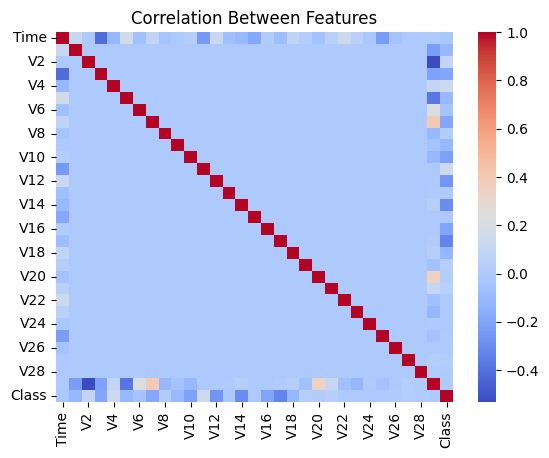

In [9]:
corr = df.corr()

sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Between Features")
plt.show()

In [10]:
x = df.drop(columns=['Class'])
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [11]:
y = pd.DataFrame(df, columns=['Class'])
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
284802,0
284803,0
284804,0
284805,0


In [14]:
y = y.values.ravel()
y

array([0, 0, 0, ..., 0, 0, 0])

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = scaler.fit_transform(x)
features

array([[-1.99658302, -0.69424232, -0.04407492, ...,  0.33089162,
        -0.06378115,  0.24496426],
       [-1.99658302,  0.60849633,  0.16117592, ..., -0.02225568,
         0.04460752, -0.34247454],
       [-1.99656197, -0.69350046, -0.81157783, ..., -0.13713686,
        -0.18102083,  1.16068593],
       ...,
       [ 1.6419735 ,  0.98002374, -0.18243372, ...,  0.01103672,
        -0.0804672 , -0.0818393 ],
       [ 1.6419735 , -0.12275539,  0.32125034, ...,  0.26960398,
         0.31668678, -0.31324853],
       [ 1.64205773, -0.27233093, -0.11489898, ..., -0.00598394,
         0.04134999,  0.51435531]])

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(227845, 56962)

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, class_weight="balanced")
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.74      0.85        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56863     1]
 [   25    73]]


In [25]:
from sklearn.linear_model import LogisticRegression

model_0 = LogisticRegression()
model_0.fit(X_train, y_train)

LogisticRegression()

In [26]:
y_pred_2 = model.predict(X_test)
cr2 = classification_report(y_test, y_pred_2)
cm2 = confusion_matrix(y_test, y_pred_2)
print(cr2)
print(cm2)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.74      0.85        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56863     1]
 [   25    73]]


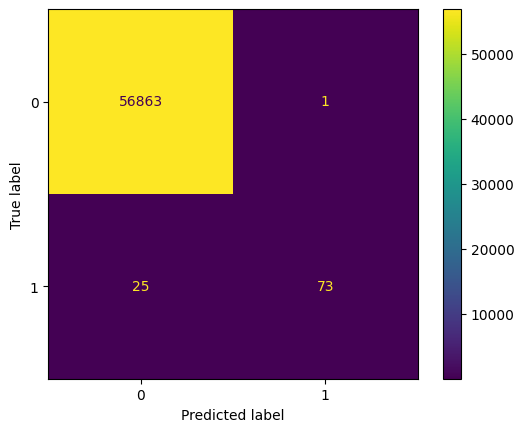

In [28]:
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [29]:
from sklearn.metrics import precision_recall_curve

p_proba = model_0.predict_proba(X_test)

In [30]:
p_proba

array([[1.11794601e-07, 9.99999888e-01],
       [9.99910581e-01, 8.94190368e-05],
       [9.99943624e-01, 5.63759569e-05],
       ...,
       [9.99521515e-01, 4.78485070e-04],
       [9.99938640e-01, 6.13595069e-05],
       [9.98511418e-01, 1.48858179e-03]])

In [31]:
y_score = p_proba[:, 1]
y_score

array([9.99999888e-01, 8.94190368e-05, 5.63759569e-05, ...,
       4.78485070e-04, 6.13595069e-05, 1.48858179e-03])

In [32]:
precision, recall, threshold = precision_recall_curve(y_test, y_score)

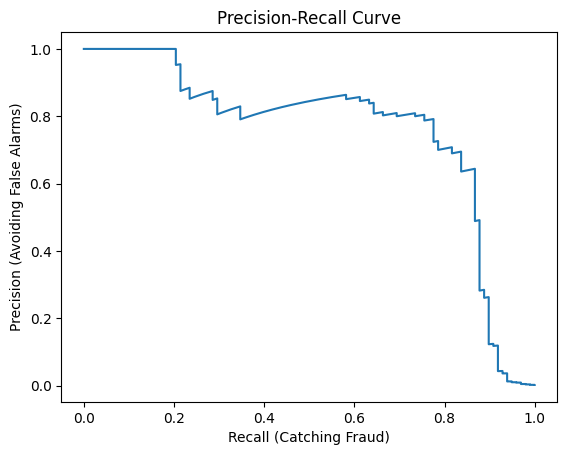

In [35]:
plt.plot(recall, precision, label="Random forest")
plt.xlabel('Recall (Catching Fraud)')
plt.ylabel('Precision (Avoiding False Alarms)')
plt.title('Precision-Recall Curve')
plt.show()

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape, y_train.shape}")
print(f"Resampled training set shape: {X_train_resampled.shape, y_train_resampled.shape}")
print(f"Class distribution before SMOTE: {pd.Series(y_train).value_counts()}")
print(f"Class distribution after SMOTE: {pd.Series(y_train_resampled).value_counts()}")

Original training set shape: ((227845, 30), (227845,))
Resampled training set shape: ((454902, 30), (454902,))
Class distribution before SMOTE: 0    227451
1       394
Name: count, dtype: int64
Class distribution after SMOTE: 0    227451
1    227451
Name: count, dtype: int64


Now, let's retrain the `RandomForestClassifier` using the resampled training data.

In [37]:
model_resampled = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
model_resampled.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', random_state=42)

Let's evaluate the performance of the model trained with resampled data on the original test set.

Classification Report (after SMOTE):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix (after SMOTE):
 [[56854    10]
 [   16    82]]


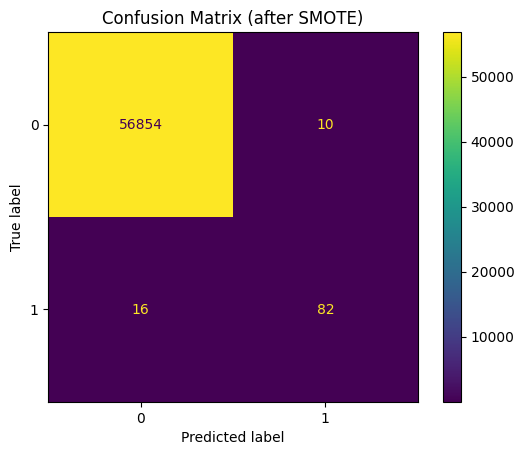

In [38]:
y_pred_resampled = model_resampled.predict(X_test)
cr_resampled = classification_report(y_test, y_pred_resampled)
cm_resampled = confusion_matrix(y_test, y_pred_resampled)

print("Classification Report (after SMOTE):\n", cr_resampled)
print("Confusion Matrix (after SMOTE):\n", cm_resampled)

ConfusionMatrixDisplay(cm_resampled).plot()
plt.title("Confusion Matrix (after SMOTE)")
plt.show()